# Imports 

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Utility Functions

In [21]:
def train_model(model, X_train, y_train, X_val, y_val, 
                epochs=200, lr=0.001, weight_decay=0):
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

In [22]:
def plot_curves(train_losses, val_losses, title):
    plt.figure()
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend(["Train", "Validation"])
    plt.show()

In [23]:
data = fetch_california_housing()

X = data.data
y = data.target.reshape(-1, 1)

# Step 0 — Sanity Check

In [24]:
# Few samples
X_small = X[:200]
y_small = y[:200]

X_train, X_val, y_train, y_val = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42
)

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [26]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [27]:
class SimpleModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

model = SimpleModel(X_train.shape[1])

train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=200, lr=0.01
)

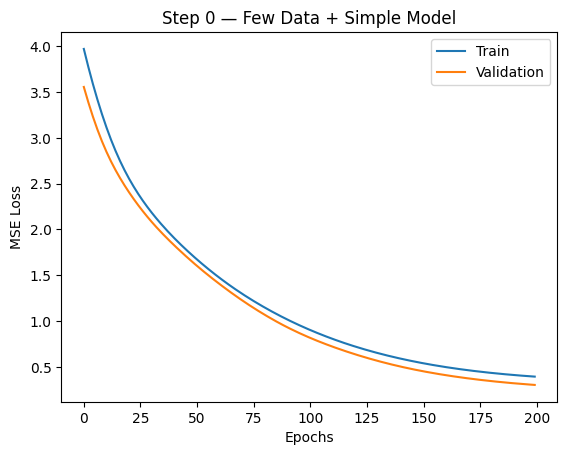

In [28]:
plot_curves(train_losses, val_losses, 
            "Step 0 — Few Data + Simple Model")

# Step 1 — Baseline

In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [31]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [32]:
model = SimpleModel(X_train.shape[1])

train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=200, lr=0.01
)

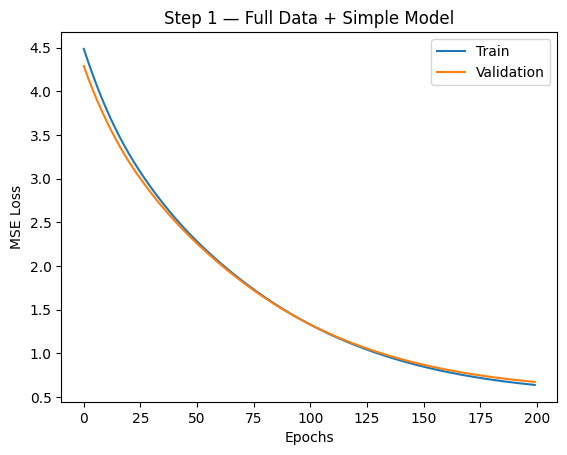

In [33]:
plot_curves(train_losses, val_losses, 
            "Step 1 — Full Data + Simple Model")

# Step 2 — Reduce Bias (Increase Model Complexity)


In [34]:
class ComplexModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ComplexModel(X_train.shape[1])

In [35]:
train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=300, lr=0.001
)

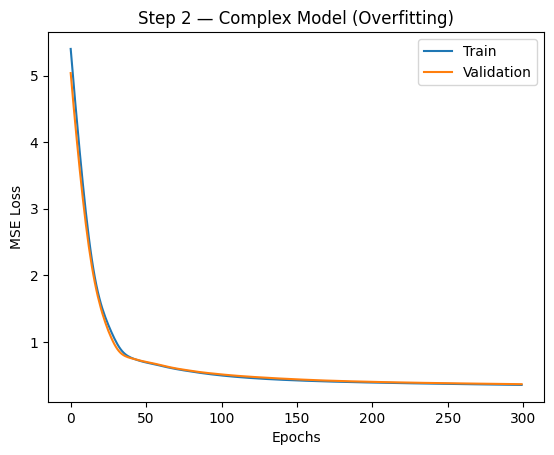

In [36]:
plot_curves(train_losses, val_losses, 
            "Step 2 — Complex Model (Overfitting)")

# Step 3 — Regularization

In [37]:
class RegularizedModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RegularizedModel(X_train.shape[1])

In [38]:
train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=300, lr=0.001, weight_decay=1e-4
)

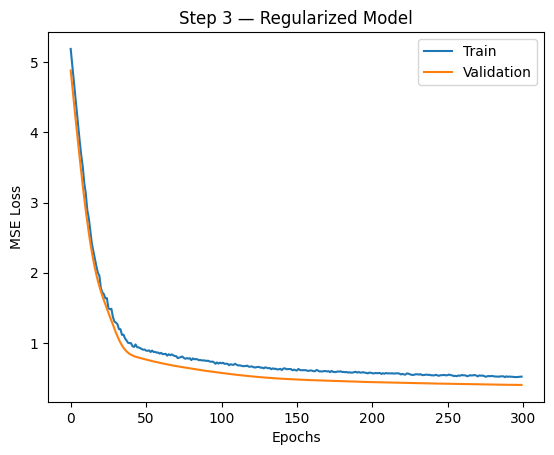

In [39]:
plot_curves(train_losses, val_losses, 
            "Step 3 — Regularized Model")

# Bias–Variance Tradeoff Explanation

Bias = Error due to overly simple assumptions.
Variance = Error due to sensitivity to training data.

Step 0 & 1:
High Bias
- Both curves high
- Model too simple

Step 2:
High Variance
- Training loss very low
- Validation loss higher
- Large gap between curves

Step 3:
Optimal Tradeoff
- Small gap
- Validation loss minimized

Goal:
Minimize validation loss, not training loss.